El glioblastoma (GBM) es uno de los tumores con mayor heterogeneidad celular, lo que convierte a los datos de secuenciación de ARN de célula única (single-cell RNA sequencing, scRNA-seq) en una herramienta especialmente relevante para estudiar su complejidad transcriptómica.

En este experimento se emplea un dataset público de glioblastoma obtenido del portal del **Broad Institute (Single Cell Portal)**, disponible en el siguiente enlace:  
https://singlecell.broadinstitute.org/single_cell/study/SCP393/single-cell-rna-seq-of-adult-and-pediatric-glioblastoma#study-download



A diferencia del experimento basado en pseudoetiquetas, en este caso se plantea un escenario supervisado utilizando la variable CellAssignment como referencia biológica para la clasificación celular.

# **Configuración**

## **Configuración de dependencias y librerías**


In [ ]:
# Instalación librerías
%pip install -q --upgrade pip setuptools wheel
!pip install -q "numpy==1.26.4" "scipy==1.12.0" "pandas==2.2.2" "matplotlib==3.8.4" "seaborn==0.13.2"
!pip install -q "h5py==3.11.0" "anndata==0.10.8" "scanpy==1.10.1" "scikit-learn==1.5.1"
!pip install -q "jedi>=0.19.1"
%pip install -q "statsmodels>=0.14" "h5py==3.11.0" "KDEpy==1.1.9"
!pip install -q igraph leidenalg

# Deep learning
%pip install -q torch==2.2.2 torchvision==0.17.2 --index-url https://download.pytorch.org/whl/cpu
%pip install -q dgl==1.1.3 -f https://data.dgl.ai/wheels/repo.html


!pip uninstall -y numpy
!pip install -q "numpy==1.26.4"
!pip install -q igraph leidenalg

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.12.0 which is incompatible.


In [ ]:
!pip install -q celltypist==1.6.3 leidenalg igraph tables
!pip uninstall -y pandas pySingleCellNet
!pip install pandas==2.1.4
!python -c "import pandas as pd; print(pd.__version__)"



Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
  Using cached pandas-2.1.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
Using cached pandas-2.1.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
mizani 0.13.5 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incompatible.
plotnine 0.14.6 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.12.0 which is incompatible.


2.1.4


Reiniciar entorno

In [ ]:
import numpy as np
import scipy
import pandas as pd
import scanpy as sc
import anndata as ad
import sklearn
import h5py
from scipy import sparse
import os
import scipy.sparse as sp
import celltypist

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    adjusted_rand_score, normalized_mutual_info_score,
    classification_report
)

from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

print("CellTypist:", celltypist.__version__)

print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("pandas:", pd.__version__)
print("scanpy:", sc.__version__)
print("anndata:", ad.__version__)
print("sklearn:", sklearn.__version__)
print("h5py:", h5py.__version__)

CellTypist: 1.6.3
numpy: 1.26.4
scipy: 1.12.0
pandas: 2.1.4
scanpy: 1.10.1
anndata: 0.10.8
sklearn: 1.5.1
h5py: 3.11.0


# **1. Conjunto de datos**

## **1.1. Carga de los datos**
Se monta Google Drive y se define la ruta en la que se encuentran almacenados los archivos utilizados en el experimento.

Después, se cargan la matriz de expresión y los metadatos. La matriz contiene los genes en filas y las células en columnas, mientras que los metadatos recogen información clínica, técnica y biológica de cada célula.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
data_dir = "/content/drive/MyDrive/Colab Notebooks/Experimento2_gliobastoma/data2"
print(os.listdir(data_dir))

['IDHwt.GBM.Metadata.SS2.txt', 'IDHwtGBM.processed.SS2.logTPM.txt']


In [ ]:
import os
import pandas as pd
import anndata as ad

#ruta de los datos
data_dir = "/content/drive/MyDrive/Colab Notebooks/Experimento2_gliobastoma/data2"

#archivos
expr_path = os.path.join(data_dir, "IDHwtGBM.processed.SS2.logTPM.txt")
meta_path = os.path.join(data_dir, "IDHwt.GBM.Metadata.SS2.txt")


#1. cargar matriz de expresión: filas = genes y columnas = células
expr = pd.read_csv(expr_path, sep="\t",index_col=0)
print("Matriz de expresión:")
print(expr.shape)
display(expr.iloc[:5, :5])


#2. cargar metadatos
metadata = pd.read_csv(meta_path, sep="\t", index_col=0)
print("\nMetadatos:")
print(metadata.shape)
display(metadata.head())

Matriz de expresión:
(23686, 7930)


,MGH101-P1-A04,MGH101-P1-A05,MGH101-P1-A07,MGH101-P1-A09,MGH101-P1-A10
GENE,,,,,
A1BG,0.0,0.000000,0.0,0.000000,0.000000
A1BG-AS1,0.0,0.000000,0.0,0.000000,0.000000
A1CF,0.0,0.000000,0.0,0.000000,0.000000
A2M,0.0,5.327184,0.0,8.698337,8.205094
A2M-AS1,0.0,0.000000,0.0,0.000000,0.000000



Metadatos:
(7931, 14)


,Sample,GBMType,CellAssignment,CrossSection,GenesExpressed,GeneticSubclone,MESlike2,MESlike1,AClike,OPClike,NPClike1,NPClike2,G1S,G2M
NAME,,,,,,,,,,,,,,
TYPE,group,group,group,group,numeric,group,numeric,numeric,numeric,numeric,numeric,numeric,numeric,numeric
MGH100-P5-A01,MGH100,Adult,Malignant,none,7403,MGH100_3,-0.235210691098538,0.292177011540687,2.23440649321884,0.410103488627058,-0.531071223619069,-0.843401360119488,-0.971652712104557,-0.308114431198222
MGH100-P5-A03,MGH100,Adult,Malignant,none,8861,NaN,-0.646138155879352,-1.2536486798915,-0.64760798179912,0.888222499315863,0.812496082965807,-0.188600125483229,3.60410116983304,1.57137909559806
MGH100-P5-A04,MGH100,Adult,Malignant,none,5957,NaN,2.25733451152936,-0.0739986658631031,-1.14362729808451,-1.46534492178769,-1.72048930991396,-0.859114889056499,-0.339476972724265,-0.322819823094577
MGH100-P5-A06,MGH100,Adult,Malignant,none,7320,MGH100_1,-0.557506241077064,-0.548720861252219,-0.799967504037717,0.448709834275037,0.418595604810981,-0.14320178100221,3.04242309618124,0.881796036949653


## **1.2. Inspección de los archivos de datos**

Se comprueba la correspondencia entre los identificadores celulares presentes en la matriz de expresión y en el archivo de metadatos.

In [ ]:
#comprobar identificadores celulares

print("\nPrimeras células expresión:")
print(expr.columns[:10].tolist())

print("\nPrimeras células metadata:")
print(metadata.index[:10].tolist())


#intersección de células
common_cells = expr.columns.intersection(metadata.index)
print("\nNúmero de células comunes:", len(common_cells))
print("Total células expresión:", expr.shape[1])
print("Total células metadata:", metadata.shape[0])


#filtrar únicamente células coincidentes
expr = expr[common_cells]
metadata = metadata.loc[common_cells]

print("\nDimensiones:")
print("Expresión:", expr.shape)
print("Metadata:", metadata.shape)



Primeras células expresión:
['MGH101-P1-A04', 'MGH101-P1-A05', 'MGH101-P1-A07', 'MGH101-P1-A09', 'MGH101-P1-A10', 'MGH101-P1-A11', 'MGH101-P1-B03', 'MGH101-P1-B04', 'MGH101-P1-B06', 'MGH101-P1-B09']

Primeras células metadata:
['TYPE', 'MGH100-P5-A01', 'MGH100-P5-A03', 'MGH100-P5-A04', 'MGH100-P5-A06', 'MGH100-P5-A07', 'MGH100-P5-A08', 'MGH100-P5-A09', 'MGH100-P5-A10', 'MGH100-P5-A12']

Número de células comunes: 7930
Total células expresión: 7930
Total células metadata: 7931

Dimensiones:
Expresión: (23686, 7930)
Metadata: (7930, 14)


## **1.3. Crear objeto AnnData**

Se construye un objeto AnnData, estructura estándar utilizada en Scanpy para el análisis de datos scRNA-seq. Para ello, la matriz se transpone, ya que AnnData organiza los datos como células por genes.

In [ ]:
# AnnData espera cells x genes
adata = ad.AnnData(X=expr.T)

# Añadir metadata
adata.obs = metadata.copy()

# Añadir nombres
adata.var_names = expr.index.astype(str)
adata.obs_names = common_cells.astype(str)


# Resumen AnnData
print("\nObjeto AnnData:")
print(adata)


#columnas disponibles clasificación
print("\nColumnas disponibles en adata.obs:")
print(adata.obs.columns.tolist())


# visualización
display(adata.obs.head())
print("\nPrimeros genes:")
print(adata.var_names[:10].tolist())

print("\nPrimeras células:")
print(adata.obs_names[:10].tolist())


Objeto AnnData:
AnnData object with n_obs × n_vars = 7930 × 23686
    obs: 'Sample', 'GBMType', 'CellAssignment', 'CrossSection', 'GenesExpressed', 'GeneticSubclone', 'MESlike2', 'MESlike1', 'AClike', 'OPClike', 'NPClike1', 'NPClike2', 'G1S', 'G2M'

Columnas disponibles en adata.obs:
['Sample', 'GBMType', 'CellAssignment', 'CrossSection', 'GenesExpressed', 'GeneticSubclone', 'MESlike2', 'MESlike1', 'AClike', 'OPClike', 'NPClike1', 'NPClike2', 'G1S', 'G2M']


,Sample,GBMType,CellAssignment,CrossSection,GenesExpressed,GeneticSubclone,MESlike2,MESlike1,AClike,OPClike,NPClike1,NPClike2,G1S,G2M
MGH101-P1-A04,MGH101,Adult,Macrophage,none,3369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MGH101-P1-A05,MGH101,Adult,Macrophage,none,3135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MGH101-P1-A07,MGH101,Adult,Macrophage,none,3442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MGH101-P1-A09,MGH101,Adult,Macrophage,none,3299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MGH101-P1-A10,MGH101,Adult,Macrophage,none,3702,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Primeros genes:
['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A2MP1', 'A4GALT', 'A4GNT', 'AA06']

Primeras células:
['MGH101-P1-A04', 'MGH101-P1-A05', 'MGH101-P1-A07', 'MGH101-P1-A09', 'MGH101-P1-A10', 'MGH101-P1-A11', 'MGH101-P1-B03', 'MGH101-P1-B04', 'MGH101-P1-B06', 'MGH101-P1-B09']


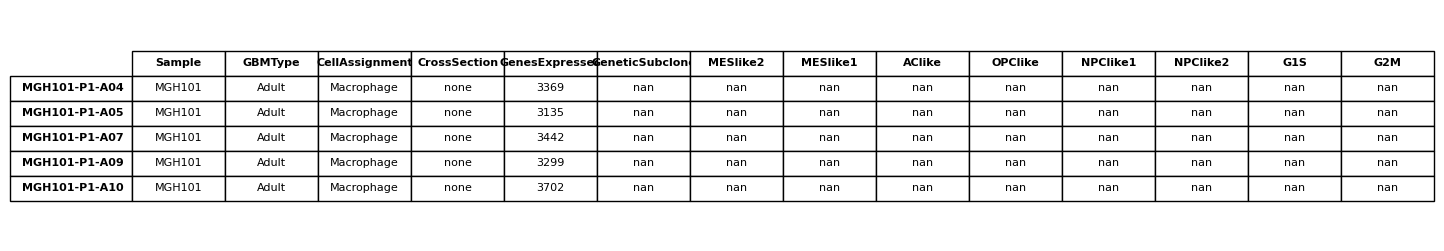

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#tabla adata
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files

# Tabla que quieres exportar como imagen
df_obs_head = adata.obs.head()

# Crear figura
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis("off")

# Crear tabla
tabla = ax.table(
    cellText=df_obs_head.values,
    colLabels=df_obs_head.columns,
    rowLabels=df_obs_head.index,
    cellLoc="center",
    loc="center"
)

# Estilo
tabla.auto_set_font_size(False)
tabla.set_fontsize(8)
tabla.scale(1.2, 1.5)

# Encabezados en negrita
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
    if col == -1:
        cell.set_text_props(weight="bold")

# Guardar imagen
nombre_imagen = "adata_obs_head.png"
plt.savefig(nombre_imagen, dpi=300, bbox_inches="tight")
plt.show()

# Descargar en Colab
files.download(nombre_imagen)

In [ ]:
# INSPECCIÓN DE ETIQUETAS

import pandas as pd

print("Distribución de CellAssignment:")
display(adata.obs["CellAssignment"].value_counts(dropna=False).to_frame("n_cells"))

print("\nDistribución de GBMType:")
display(adata.obs["GBMType"].value_counts(dropna=False).to_frame("n_cells"))

print("\nDistribución por paciente/muestra:")
display(adata.obs["Sample"].value_counts(dropna=False).to_frame("n_cells"))

Distribución de CellAssignment:


,n_cells
CellAssignment,
Malignant,6863
Macrophage,754
Oligodendrocyte,219
T-cell,94



Distribución de GBMType:


,n_cells
GBMType,
Adult,5742
Pediatric,2188



Distribución por paciente/muestra:


,n_cells
Sample,
MGH105,634
MGH66,436
MGH125,399
MGH124,370
MGH110,359
MGH104,355
BT771,339
BT1160,335
BT749,317


# **2. Procesamiento de los datos**


In [ ]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

#copia
adata_pp = adata.copy()

print("AnnData inicial:")
print(adata_pp)

AnnData inicial:
AnnData object with n_obs × n_vars = 7930 × 23686
    obs: 'Sample', 'GBMType', 'CellAssignment', 'CrossSection', 'GenesExpressed', 'GeneticSubclone', 'MESlike2', 'MESlike1', 'AClike', 'OPClike', 'NPClike1', 'NPClike2', 'G1S', 'G2M'


## **2.1. Control de calidad**

Métricas de calidad celular.


In [ ]:
# Cálculo de métricas generales de QC
sc.pp.calculate_qc_metrics(adata_pp, inplace=True, log1p=True)

print("Columnas de QC añadidas a adata_qc.obs:")
print(adata_pp.obs.columns.tolist())

print("\nResumen QC:")
display(adata_pp.obs[["total_counts", "n_genes_by_counts"]].describe())

Columnas de QC añadidas a adata_qc.obs:
['Sample', 'GBMType', 'CellAssignment', 'CrossSection', 'GenesExpressed', 'GeneticSubclone', 'MESlike2', 'MESlike1', 'AClike', 'OPClike', 'NPClike1', 'NPClike2', 'G1S', 'G2M', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes']

Resumen QC:


,total_counts,n_genes_by_counts
count,7930.000000,7930.000000
mean,14519.811558,5735.108953
std,2839.279830,1422.089176
min,4976.759348,3003.000000
25%,12586.779318,4639.250000
50%,14759.215134,5661.000000
75%,16586.500544,6752.000000
max,24183.826465,11890.000000


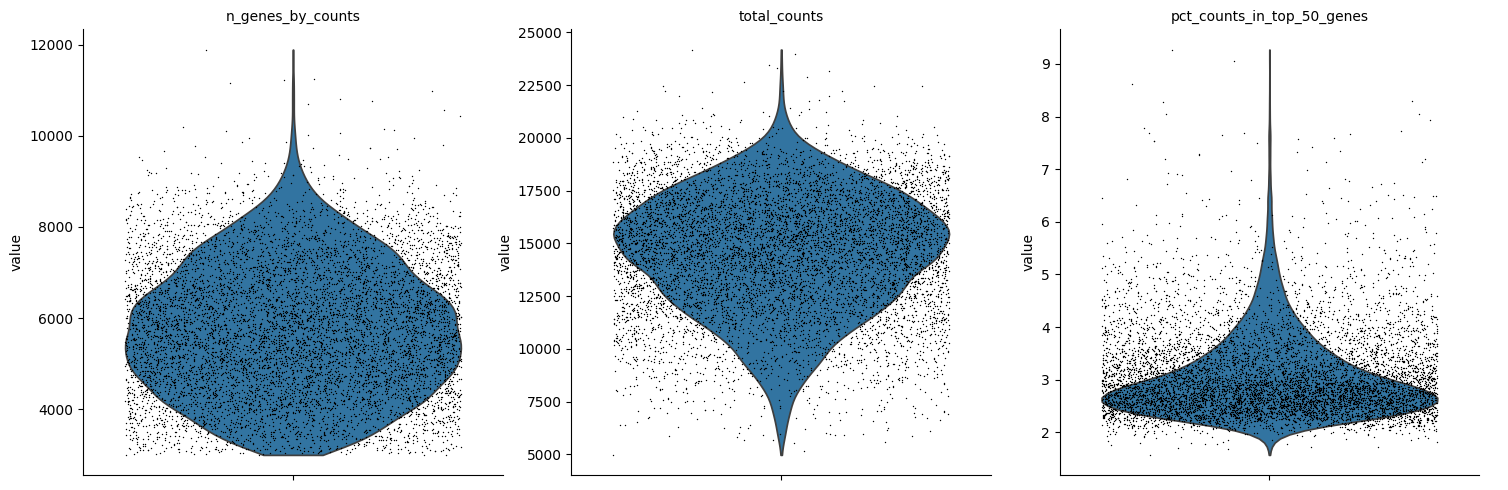

In [ ]:
# Visualización de métricas básicas de QC
sc.pl.violin(
    adata_pp,
    ["n_genes_by_counts", "total_counts", "pct_counts_in_top_50_genes"],
    jitter=0.4,
    multi_panel=True
)

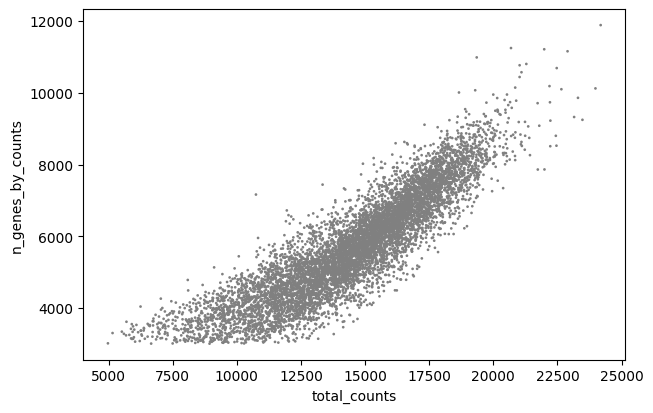

In [ ]:
# Relación entre número total de conteos y número de genes detectados
sc.pl.scatter(
    adata_pp,
    x="total_counts",
    y="n_genes_by_counts"
)

Filtrado

In [ ]:
print("Dimensiones antes del filtrado básico:", adata_pp.shape)

# Filtrado básico
sc.pp.filter_cells(adata_pp, min_genes=100)
sc.pp.filter_genes(adata_pp, min_cells=3)

print("Dimensiones después del filtrado:", adata_pp.shape)

Dimensiones antes del filtrado básico: (7930, 23686)
Dimensiones después del filtrado: (7930, 22197)


In [ ]:
#conservar únicamente genes detectados en al menos 20 células
print(f"Número total de genes antes del filtrado: {adata_pp.n_vars}")

sc.pp.filter_genes(adata_pp, min_cells=20)

print(f"Número de genes tras el filtrado: {adata_pp.n_vars}")

Número total de genes antes del filtrado: 22197
Número de genes tras el filtrado: 19949


Detección de dobletes

In [ ]:
#detección dobletes
import scanpy as sc
from scipy import sparse

# Mantener matriz sparse
if not sparse.issparse(adata_pp.X):
    adata_pp.X = sparse.csr_matrix(adata_pp.X)

#Detección de dobles con Scrublet
sc.pp.scrublet(
    adata_pp,
    n_neighbors=10,
    n_prin_comps=20,
    sim_doublet_ratio=1.0,
    random_state=42
)

print("Columnas añadidas a adata_pp.obs:")
print([col for col in adata_pp.obs.columns if "doublet" in col.lower()])

print("\nResumen de clasificación de dobles:")
print(adata_pp.obs["predicted_doublet"].value_counts())

print("\nDimensiones tras eliminar dobletes:")
print(adata_pp.shape)

Columnas añadidas a adata_pp.obs:
['doublet_score', 'predicted_doublet']

Resumen de clasificación de dobles:
predicted_doublet
False    7876
True       54
Name: count, dtype: int64

Dimensiones tras eliminar dobletes:
(7930, 19949)


In [ ]:
adata_pp.obs[["doublet_score", "predicted_doublet"]].head()

,doublet_score,predicted_doublet
MGH101-P1-A04,0.008242,False
MGH101-P1-A05,0.008242,False
MGH101-P1-A07,0.008242,False
MGH101-P1-A09,0.002500,False
MGH101-P1-A10,0.008242,False


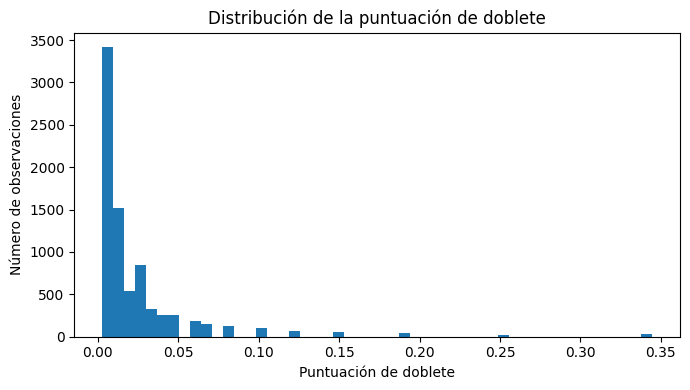

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(adata_pp.obs["doublet_score"], bins=50)

plt.xlabel("Puntuación de doblete")
plt.ylabel("Número de observaciones")
plt.title("Distribución de la puntuación de doblete")

plt.tight_layout()
plt.show()

## **2.2. Normalización**

En este caso no se aplica una nueva normalización, ya que el subconjunto Smart-seq2 utilizado se encuentra previamente transformado.

*SMARTSEQ2 GBM (SCP393): subconjunto ya normalizado como log2(TPM/10 + 1)*

## **2.3. Selección de características: HVGs**
Se seleccionan los 2000 genes altamente variables, que concentran mayor variabilidad informativa entre células.


Número de HVGs seleccionados:
2000


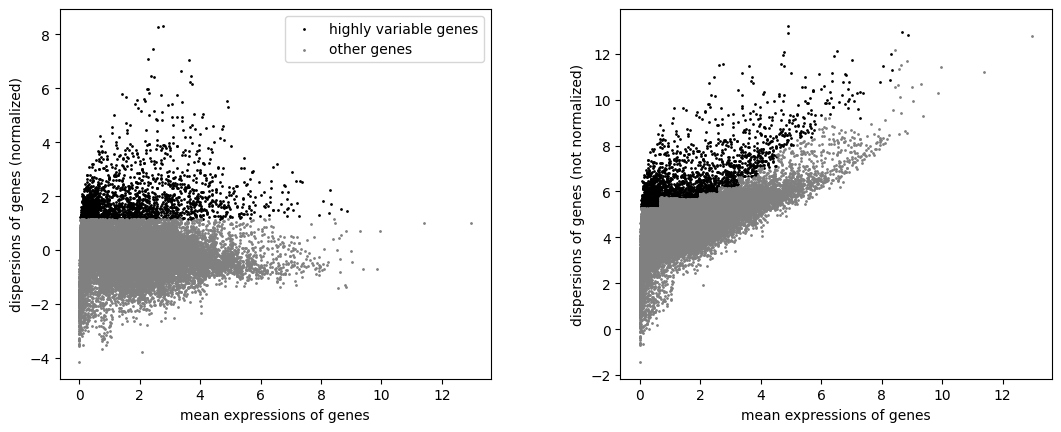

In [ ]:
# Identificación de genes altamente variables
sc.pp.highly_variable_genes(adata_pp, n_top_genes=2000)
print("\nNúmero de HVGs seleccionados:")
print(adata_pp.var["highly_variable"].sum())

# Visualización de los genes seleccionados
sc.pl.highly_variable_genes(adata_pp)

In [ ]:
#copia adata_pp: subconjunto HVGs
adata_hvg = adata_pp[:, adata_pp.var["highly_variable"]].copy()

print("\nAnnData tras HVGs:")
print(adata_hvg)


AnnData tras HVGs:
AnnData object with n_obs × n_vars = 7930 × 2000
    obs: 'Sample', 'GBMType', 'CellAssignment', 'CrossSection', 'GenesExpressed', 'GeneticSubclone', 'MESlike2', 'MESlike1', 'AClike', 'OPClike', 'NPClike1', 'NPClike2', 'G1S', 'G2M', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'scrublet', 'hvg'


## **2.4. Reducción de dimensionalidad**

PCA

In [ ]:
# PCA sobre HVGs
sc.pp.pca(adata_hvg, svd_solver="arpack")

print("PCA completado")

PCA completado


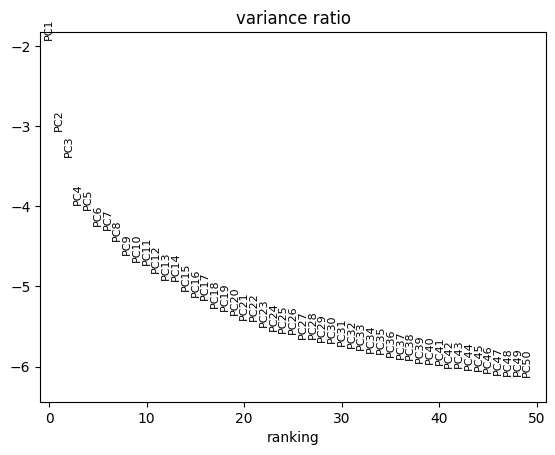

In [ ]:
#Selección del número de componentes principales

#varianza explicada
sc.pl.pca_variance_ratio(
    adata_hvg,
    n_pcs=50,
    log=True
)

Grafo de vencinos

In [ ]:
sc.pp.neighbors(adata_hvg, n_neighbors=10, n_pcs=40)

UMAP


UMAP calculado.


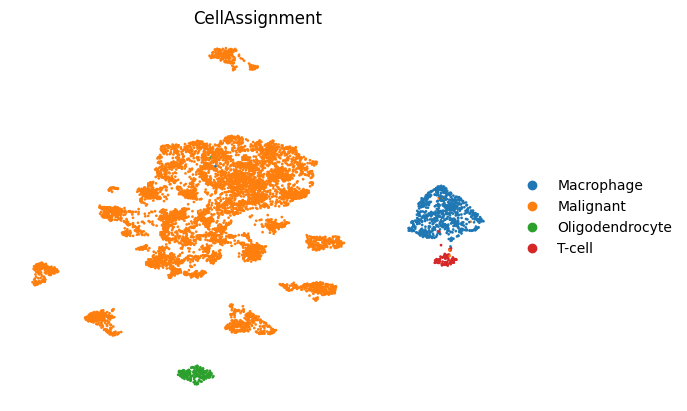

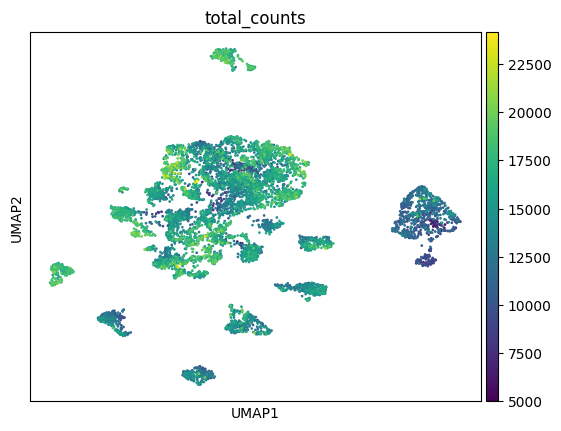

In [ ]:
#UMAP
sc.tl.umap(adata_hvg)
print("\nUMAP calculado.")

#visualización
sc.pl.umap(adata_hvg, color="CellAssignment", frameon=False)
sc.pl.umap(adata_hvg, color="total_counts")

Proyección alternativa con t-SNE

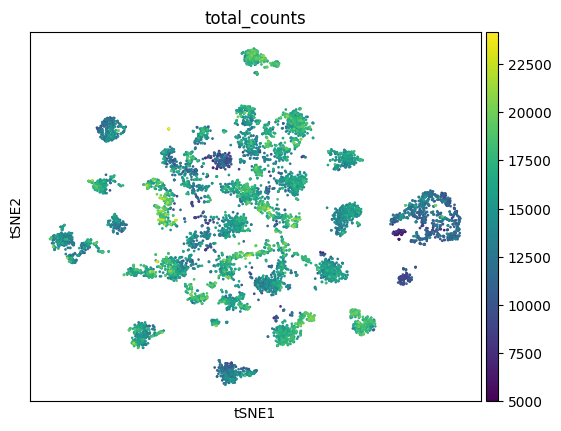

In [ ]:
sc.tl.tsne(adata_hvg, use_rep="X_pca")

sc.pl.tsne(adata_hvg, color="total_counts")

Inspección de métricas de calidad en el espacio reducido

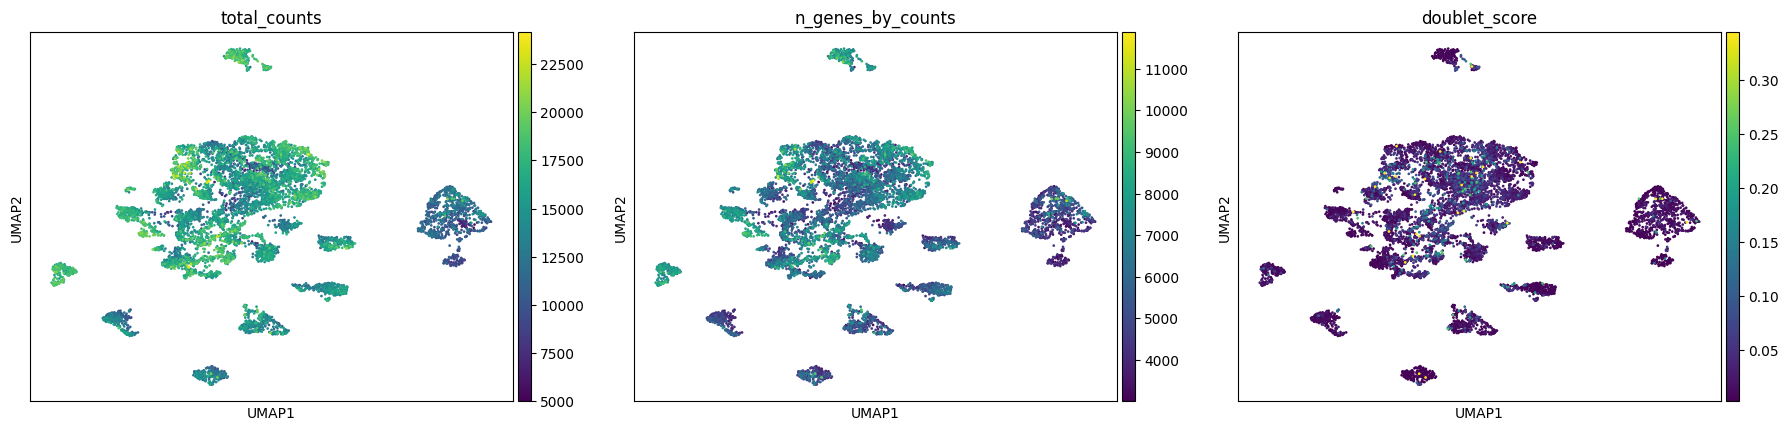

In [ ]:
sc.pl.umap(
    adata_hvg,
    color=[
        "total_counts",
        "n_genes_by_counts",
        "doublet_score"
    ]
)

## **2.5. Clustering: algoritmo de Leiden**
Se aplica el algoritmo de Leiden sobre el grafo de vecinos para identificar agrupaciones celulares.

Se prueban distintas resoluciones para observar cómo cambia el número y la granularidad de los clusters.

In [ ]:
# Aplicación de Leiden (resolución por defecto)
sc.tl.leiden(adata_hvg, flavor="igraph", n_iterations=2)

print("Clustering Leiden completado")
print("Número de clusters:", adata_hvg.obs["leiden"].nunique())

Clustering Leiden completado
Número de clusters: 33


In [ ]:
#resoluciones de Leiden
# Diferentes resoluciones de Leiden
sc.tl.leiden(adata_hvg, resolution=0.2, key_added="leiden_res_0_2", flavor="igraph", n_iterations=2)
sc.tl.leiden(adata_hvg, resolution=0.25, key_added="leiden_res_0_25", flavor="igraph", n_iterations=2)
sc.tl.leiden(adata_hvg, resolution=0.5, key_added="leiden_res_0_5", flavor="igraph", n_iterations=2)
sc.tl.leiden(adata_hvg, resolution=1.0, key_added="leiden_res_1", flavor="igraph", n_iterations=2) #igual que por defecto

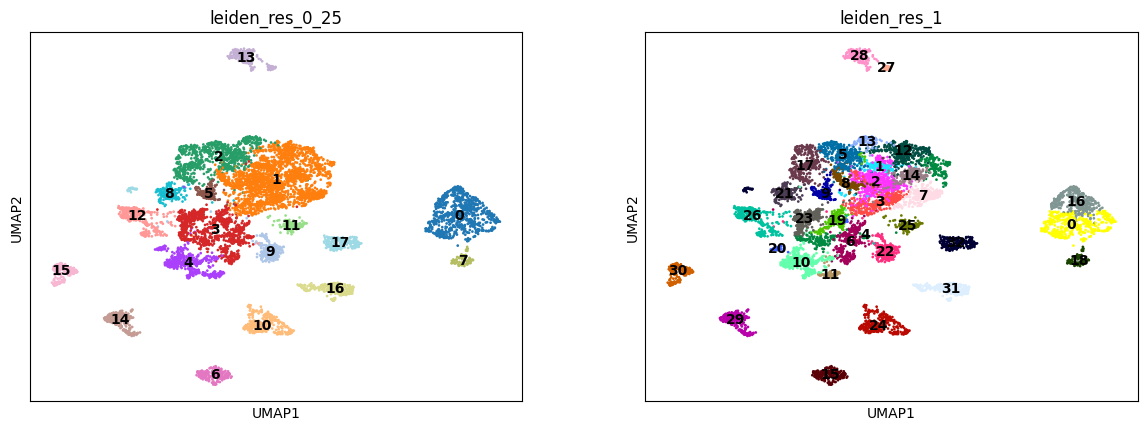

In [ ]:
#visualización
sc.pl.umap(
    adata_hvg,
    color=["leiden_res_0_25", "leiden_res_1"],
    legend_loc="on data"
)


Clusters Leiden generados.


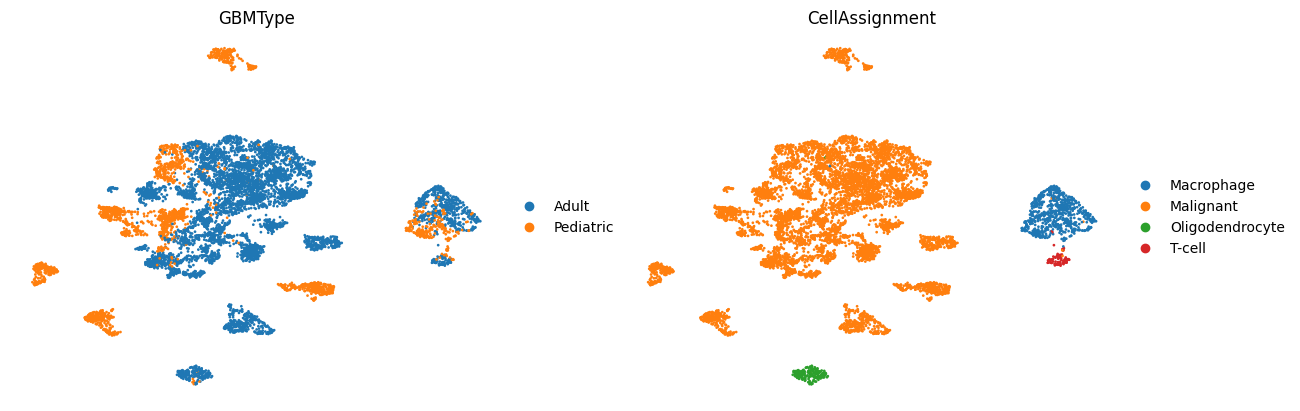

In [ ]:
sc.tl.leiden(adata_hvg, resolution=1.0)
print("\nClusters Leiden generados.")

#UMAP clusters
sc.pl.umap(adata_hvg, color=["GBMType", "CellAssignment"], frameon=False)

## Resumen del procesamiento de los datos

In [ ]:
print("\nObjeto final preprocesado:")
print(adata_hvg)

print("\nClases disponibles:")
print(adata_hvg.obs["CellAssignment"].value_counts())

print("\nPrimeros genes altamente variables:")
print(adata_hvg.var_names[:20].tolist())


Objeto final preprocesado:
AnnData object with n_obs × n_vars = 7930 × 2000
    obs: 'Sample', 'GBMType', 'CellAssignment', 'CrossSection', 'GenesExpressed', 'GeneticSubclone', 'MESlike2', 'MESlike1', 'AClike', 'OPClike', 'NPClike1', 'NPClike2', 'G1S', 'G2M', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'leiden_res_0_2', 'leiden_res_0_25', 'leiden_res_0_5', 'leiden_res_1'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'scrublet', 'hvg', 'pca', 'neighbors', 'umap', 'CellAssignment_colors', 'tsne', 'leiden', 'leiden_res_0_2', 'leiden_res_0_25', 'leiden_res_0_5', 'leiden_res_1', 'leiden_res_0_25_colors', 'le

# **3. Técnicas de machine learning y deep learning: entrenamiento de modelos**

ENTRENAMIENTO DE MODELOS - GBM SMARTSEQ2
* **Modelos:** SVM, Random Forest, ACTINN, CellTypist, PySingleCellNet
* **Ground truth:** CellAssignment
* **Entrada:** adata_hvg

### Configuración y librerías

In [ ]:
!pip install -q celltypist==1.6.3 leidenalg igraph tables
!pip uninstall -y pandas pySingleCellNet
!pip install pandas==2.1.4
!python -c "import pandas as pd; print(pd.__version__)"

import os
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import celltypist

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    adjusted_rand_score, normalized_mutual_info_score,
    classification_report
)

from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

print("CellTypist:", celltypist.__version__)


Found existing installation: pandas 2.1.4
Uninstalling pandas-2.1.4:
  Successfully uninstalled pandas-2.1.4
  Using cached pandas-2.1.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
Using cached pandas-2.1.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
mizani 0.13.5 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incompatible.
plotnine 0.14.6 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.12.0 which is incompatible.


2.1.4


KeyboardInterrupt: 

## **3.1. Datos**

In [ ]:
target_col = "CellAssignment"

adata_model = adata_hvg.copy()
adata_model = adata_model[~adata_model.obs[target_col].isna()].copy()
adata_model.obs[target_col] = adata_model.obs[target_col].astype("category")

#matrix
X = adata_model.X
if sp.issparse(X):
    X = X.toarray()
X = np.asarray(X, dtype=np.float32)

#etiquetas
y_labels = adata_model.obs[target_col].astype(str).values

#codificación etiquetas
le = LabelEncoder()
y = le.fit_transform(y_labels)

print("Dimensión X:", X.shape)
print("Número de clases:", len(le.classes_))
print("Clases:", le.classes_)

Dimensión X: (7930, 2000)
Número de clases: 4
Clases: ['Macrophage' 'Malignant' 'Oligodendrocyte' 'T-cell']


In [ ]:
#train / test split
idx = np.arange(adata_model.n_obs)

idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)

X_train = X[idx_train]
X_test = X[idx_test]
y_train = y[idx_train]
y_test = y[idx_test]

adata_train = adata_model[idx_train].copy()
adata_test = adata_model[idx_test].copy()

print("\nTrain:", X_train.shape)
print("Test:", X_test.shape)


Train: (6344, 2000)
Test: (1586, 2000)


## **3.2. Modelos**

In [ ]:
#ejecutar antes esta celda que el entranamiento de cada modelo, para así poder crear un tabla final de resultados

#función evaluación
resultados = []
predicciones_modelos = {}

def evaluar_modelo(nombre, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    precision_macro = precision_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    recall_macro = recall_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    f1_macro = f1_score(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted = precision_score(
        y_true, y_pred, average="weighted", zero_division=0
    )
    recall_weighted = recall_score(
        y_true, y_pred, average="weighted", zero_division=0
    )
    f1_weighted = f1_score(
        y_true, y_pred, average="weighted", zero_division=0
    )

    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)

    resultados.append({
        "modelo": nombre,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "ARI": ari,
        "NMI": nmi
    })

    predicciones_modelos[nombre] = {
        "y_true": y_true,
        "y_pred": y_pred
    }

    print("\n" + "="*70)
    print(nombre)
    print("="*70)
    print(f"Accuracy:          {acc:.4f}")
    print(f"Balanced accuracy: {bal_acc:.4f}")
    print(f"F1 macro:          {f1_macro:.4f}")
    print(f"F1 weighted:       {f1_weighted:.4f}")
    print(f"ARI:               {ari:.4f}")
    print(f"NMI:               {nmi:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=le.classes_,
            zero_division=0
        )
    )

### SVM

In [ ]:
svm_model = make_pipeline(
    MaxAbsScaler(),
    LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=5000
    )
)

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

evaluar_modelo("SVM", y_test, y_pred_svm)


SVM
Accuracy:          0.9994
Balanced accuracy: 0.9943
F1 macro:          0.9970
F1 weighted:       0.9994
ARI:               0.9969
NMI:               0.9918

Classification report:
                 precision    recall  f1-score   support

     Macrophage       1.00      1.00      1.00       151
      Malignant       1.00      1.00      1.00      1372
Oligodendrocyte       1.00      0.98      0.99        44
         T-cell       1.00      1.00      1.00        19

       accuracy                           1.00      1586
      macro avg       1.00      0.99      1.00      1586
   weighted avg       1.00      1.00      1.00      1586



### Random forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

evaluar_modelo("Random Forest", y_test, y_pred_rf)


Random Forest
Accuracy:          0.9981
Balanced accuracy: 0.9795
F1 macro:          0.9893
F1 weighted:       0.9981
ARI:               0.9906
NMI:               0.9751

Classification report:
                 precision    recall  f1-score   support

     Macrophage       1.00      0.99      1.00       151
      Malignant       1.00      1.00      1.00      1372
Oligodendrocyte       1.00      0.98      0.99        44
         T-cell       1.00      0.95      0.97        19

       accuracy                           1.00      1586
      macro avg       1.00      0.98      0.99      1586
   weighted avg       1.00      1.00      1.00      1586



### ACTINN

In [ ]:
# ============================================================
# ACTINN ORIGINAL
# Usa el split ya creado: X_train, X_test, y_train, y_test
# ============================================================

!git clone https://github.com/mafeiyang/ACTINN.git

!python ACTINN/actinn_predict.py -h

fatal: destination path 'ACTINN' already exists and is not an empty directory.
2026-05-18 09:47:50.247884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779097670.293510   17669 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779097670.306228   17669 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Instructions for updating:
non-resource variables are not supported in the long term
usage: actinn_predict.py [-h] [-trs TRAIN_SET] [-trl TRAIN_LABEL]
                         [-ts TEST_SET] [-lr LEARNING_RATE] [-ne NUM_EPOCHS]
                         [-ms MINIBATCH_SIZE] [-pc PRINT_COST]
                         [-op OUTPUT_PROBABILITY]

options:
  -h, -

In [ ]:
# ============================================================
# 2. Parchear ACTINN para TensorFlow 2.x
# ============================================================

path = "ACTINN/actinn_predict.py"

with open(path, "r") as f:
    code = f.read()

code = code.replace(
    "import tensorflow as tf",
    "import tensorflow.compat.v1 as tf\n"
    "tf.disable_v2_behavior()"
)

code = code.replace(
    "tf.contrib.layers.xavier_initializer(seed = 3)",
    "tf.keras.initializers.GlorotUniform(seed=3)"
)

code = code.replace(
    "tf.contrib.layers.xavier_initializer(seed=3)",
    "tf.keras.initializers.GlorotUniform(seed=3)"
)

code = code.replace(
    "p = tf.nn.softmax(z4, axis=0)",
    "p = tf.exp(z4) / tf.reduce_sum(tf.exp(z4), axis=0, keepdims=True)"
)

code = code.replace(
    "p = tf.nn.softmax(z4, dim=0)",
    "p = tf.exp(z4) / tf.reduce_sum(tf.exp(z4), axis=0, keepdims=True)"
)

with open(path, "w") as f:
    f.write(code)

print("ACTINN preparado")

ACTINN preparado


In [ ]:
# ============================================================
# PREPARAR ARCHIVOS PARA ACTINN
# ============================================================

import os
import numpy as np
import pandas as pd
from scipy import sparse

X_train_actinn = np.asarray(X_train)
X_test_actinn  = np.asarray(X_test)

genes = adata_model.var_names.astype(str).values

cells_train = [f"train_{i}" for i in range(X_train_actinn.shape[0])]
cells_test  = [f"test_{i}" for i in range(X_test_actinn.shape[0])]

# ACTINN espera genes x células
train_df = pd.DataFrame(
    X_train_actinn.T,
    index=genes,
    columns=cells_train
)

test_df = pd.DataFrame(
    X_test_actinn.T,
    index=genes,
    columns=cells_test
)

train_labels = pd.DataFrame({
    "cell": cells_train,
    "label": y_train.astype(str)
})

test_labels = pd.DataFrame({
    "cell": cells_test,
    "true_label": y_test.astype(int)
})

train_df.to_hdf("actinn_train_set.h5", key="dge", mode="w")
test_df.to_hdf("actinn_test_set.h5", key="dge", mode="w")

train_labels.to_csv(
    "actinn_train_label.txt.gz",
    sep="\t",
    index=False,
    header=False,
    compression="gzip"
)

test_labels.to_csv(
    "actinn_test_true_labels.csv",
    index=False
)

print("Archivos ACTINN creados:")
for f in [
    "actinn_train_set.h5",
    "actinn_test_set.h5",
    "actinn_train_label.txt.gz",
    "actinn_test_true_labels.csv"
]:
    print(f, "->", os.path.exists(f))

Archivos ACTINN creados:
actinn_train_set.h5 -> True
actinn_test_set.h5 -> True
actinn_train_label.txt.gz -> True
actinn_test_true_labels.csv -> True


In [ ]:
# ============================================================
# 3. Ejecutar ACTINN
# ============================================================

!python ACTINN/actinn_predict.py \
    -trs actinn_train_set.h5 \
    -trl actinn_train_label.txt.gz \
    -ts actinn_test_set.h5 \
    -lr 0.0001 \
    -ne 50 \
    -ms 128 \
    -pc True \
    -op False

2026-05-18 09:48:04.627780: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779097684.671313   17746 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779097684.683724   17746 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Instructions for updating:
non-resource variables are not supported in the long term
Cell Types in training set: {0: 0, 1: 1, 2: 2, 3: 3}
# Trainng cells: 6344
2026-05-18 09:48:11.221643: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1779097691.223719   17746 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization

In [ ]:
# ============================================================
# 4. Predicciones y evaluar
# ============================================================

pred_actinn = pd.read_csv("predicted_label.txt", sep="\t")
pred_actinn.columns = ["cell", "predicted_label"]

true_actinn = pd.read_csv("actinn_test_true_labels.csv")

eval_actinn = true_actinn.merge(pred_actinn, on="cell", how="inner")

y_true_actinn = eval_actinn["true_label"].astype(int).values
y_pred_actinn = eval_actinn["predicted_label"].astype(int).values

evaluar_modelo("ACTINN", y_true_actinn, y_pred_actinn)


ACTINN
Accuracy:          0.9987
Balanced accuracy: 0.9812
F1 macro:          0.9902
F1 weighted:       0.9987
ARI:               0.9939
NMI:               0.9841

Classification report:
                 precision    recall  f1-score   support

     Macrophage       1.00      1.00      1.00       151
      Malignant       1.00      1.00      1.00      1372
Oligodendrocyte       1.00      0.98      0.99        44
         T-cell       1.00      0.95      0.97        19

       accuracy                           1.00      1586
      macro avg       1.00      0.98      0.99      1586
   weighted avg       1.00      1.00      1.00      1586



### CellTypist

In [ ]:
# ============================================================
# CellTypist
# ============================================================

adata_celltypist = adata_model.copy()

adata_celltypist.obs["celltypist_label"] = (
    adata_celltypist.obs[target_col]
    .astype(str)
    .astype("category")
)

# CellTypist espera expresión log1p normalizada a 10.000 cuentas por célula.
# Si existe una capa de counts, se usa; si no, se renormaliza la matriz actual.
if "counts" in adata_celltypist.layers:
    adata_celltypist.X = adata_celltypist.layers["counts"].copy()
elif "original" in adata_celltypist.layers:
    adata_celltypist.X = adata_celltypist.layers["original"].copy()

sc.pp.normalize_total(adata_celltypist, target_sum=1e4)
sc.pp.log1p(adata_celltypist)

adata_train_ct = adata_celltypist[idx_train].copy()
adata_test_ct = adata_celltypist[idx_test].copy()

adata_train_ct.obs["celltypist_label"] = (
    adata_train_ct.obs["celltypist_label"]
    .astype("category")
)

if hasattr(adata_train_ct.X, "toarray"):
    adata_train_ct.X = adata_train_ct.X.toarray()

if hasattr(adata_test_ct.X, "toarray"):
    adata_test_ct.X = adata_test_ct.X.toarray()

celltypist_model = celltypist.train(
    adata_train_ct,
    labels="celltypist_label",
    n_jobs=4,
    feature_selection=True,
    check_expression=True
)

pred_celltypist = celltypist.annotate(
    adata_test_ct,
    model=celltypist_model,
    majority_voting=False
)

y_pred_celltypist_labels = (
    pred_celltypist.predicted_labels["predicted_labels"]
    .astype(str)
    .values
)

y_pred_celltypist = le.transform(y_pred_celltypist_labels)
y_test_celltypist = le.transform(
    adata_test_ct.obs[target_col].astype(str).values
)

evaluar_modelo("CellTypist", y_test_celltypist, y_pred_celltypist)


CellTypist
Accuracy:          0.9987
Balanced accuracy: 0.9941
F1 macro:          0.9961
F1 weighted:       0.9987
ARI:               0.9936
NMI:               0.9829

Classification report:
                 precision    recall  f1-score   support

     Macrophage       0.99      1.00      1.00       151
      Malignant       1.00      1.00      1.00      1372
Oligodendrocyte       1.00      0.98      0.99        44
         T-cell       1.00      1.00      1.00        19

       accuracy                           1.00      1586
      macro avg       1.00      0.99      1.00      1586
   weighted avg       1.00      1.00      1.00      1586




### PySingleCellNet

In [ ]:
# ============================================================
# PySingleCellNet
# ============================================================

!pip install git+https://github.com/CahanLab/PySingleCellNet.git

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib
import matplotlib.pyplot as plt

# Parche por compatibilidad con algunas versiones de matplotlib
plt.Colormap = matplotlib.colors.Colormap

import pySingleCellNet as cn

  Cloning https://github.com/CahanLab/PySingleCellNet.git to /tmp/pip-req-build-1kqdys0l
  Running command git clone --filter=blob:none --quiet https://github.com/CahanLab/PySingleCellNet.git /tmp/pip-req-build-1kqdys0l
  Resolved https://github.com/CahanLab/PySingleCellNet.git to commit 09f8f10cd2508068e4e690abd9966930622f9d6c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 31.2 MB/s  0:00:00
  Created wheel for pySingleCellNet: filename=pysinglecellnet-0.1.4-py3-none-any.whl size=116528 sha256=1dfc0ba7e31cd687cb9d232272829e377cde0cd8c0c81f27f511ca81e3bf517d
  Stored in directory: /tmp/pip-ephem-wheel-cache-u26fxeu6/wheels/53/2c/92/0e19676ce4146d6c3f9aad2dc869573c66cd35495c6e0bf189
Successfully built pySingleCellNet
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [pySingleCellNet]


In [ ]:
# ============================================================
# 1. Preparar datos para PySingleCellNet
# ============================================================

adata_scn = adata_model.copy()

adata_scn.obs["scn_label"] = (
    adata_scn.obs[target_col]
    .astype(str)
    .astype("category")
)

adTrain_scn = adata_scn[idx_train].copy()
adTest_scn  = adata_scn[idx_test].copy()

print(adTrain_scn)
print(adTest_scn)

print(adTrain_scn.obs["scn_label"].value_counts())

AnnData object with n_obs × n_vars = 6344 × 2000
    obs: 'Sample', 'GBMType', 'CellAssignment', 'CrossSection', 'GenesExpressed', 'GeneticSubclone', 'MESlike2', 'MESlike1', 'AClike', 'OPClike', 'NPClike1', 'NPClike2', 'G1S', 'G2M', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'leiden_res_0_2', 'leiden_res_0_25', 'leiden_res_0_5', 'leiden_res_1', 'scn_label'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'scrublet', 'hvg', 'pca', 'neighbors', 'umap', 'CellAssignment_colors', 'tsne', 'leiden', 'leiden_res_0_2', 'leiden_res_0_25', 'leiden_res_0_5', 'leiden_res_1', 'leiden_res_0_25_colors', 'leiden_res_1_colo

In [ ]:
# ============================================================
# 2. Entrenar clasificador
# ============================================================

groupby = "scn_label"

clf_scn = cn.tl.train_classifier(
    adTrain_scn,
    groupby,
    nRand=100,
    nTopGenes=30,
    nTopGenePairs=40,
    n_comps=30
)

print("Clasificador PySingleCellNet entrenado")

/tmp/ipython-input-44-4044133684.py:7: DeprecationWarning: nRand is deprecated, use n_rand instead
  clf_scn = cn.tl.train_classifier(
/tmp/ipython-input-44-4044133684.py:7: DeprecationWarning: nTopGenes is deprecated, use n_top_genes instead
  clf_scn = cn.tl.train_classifier(
/tmp/ipython-input-44-4044133684.py:7: DeprecationWarning: nTopGenePairs is deprecated, use n_top_gene_pairs instead
  clf_scn = cn.tl.train_classifier(


Training classifier |████████████████████████████████████████| 5/5 [100%] in 21.9s (0.23/s) 
Clasificador PySingleCellNet entrenado


In [ ]:
# ============================================================
# 3. Clasificar células de test
# ============================================================

cn.tl.classify_anndata(adTest_scn, clf_scn)

adTest_scn.obs[[
    "scn_label",
    "SCN_class_argmax"
]].head()

,scn_label,SCN_class_argmax
MGH100-P8-F03,Malignant,Malignant
MGH66-P08-F02,Malignant,Malignant
BT1187-P3-B04,T-cell,Malignant
MGH121-P4-D03,Malignant,Malignant
MGH105C-H01,Macrophage,Macrophage


In [ ]:
# ============================================================
# 4. Evaluación
# ============================================================

# eliminar predicciones "rand"
mask_valid = y_pred_scn_labels != "rand"

y_true_scn_labels = y_true_scn_labels[mask_valid]
y_pred_scn_labels = y_pred_scn_labels[mask_valid]

# transformar etiquetas válidas
y_true_scn = le.transform(y_true_scn_labels)
y_pred_scn = le.transform(y_pred_scn_labels)

evaluar_modelo(
    "SingleCellNet",
    y_true_scn,
    y_pred_scn
)


SingleCellNet
Accuracy:          0.9975
Balanced accuracy: 0.9793
F1 macro:          0.9883
F1 weighted:       0.9975
ARI:               0.9873
NMI:               0.9661

Classification report:
                 precision    recall  f1-score   support

     Macrophage       0.99      0.99      0.99       151
      Malignant       1.00      1.00      1.00      1371
Oligodendrocyte       1.00      0.98      0.99        44
         T-cell       1.00      0.95      0.97        19

       accuracy                           1.00      1585
      macro avg       1.00      0.98      0.99      1585
   weighted avg       1.00      1.00      1.00      1585



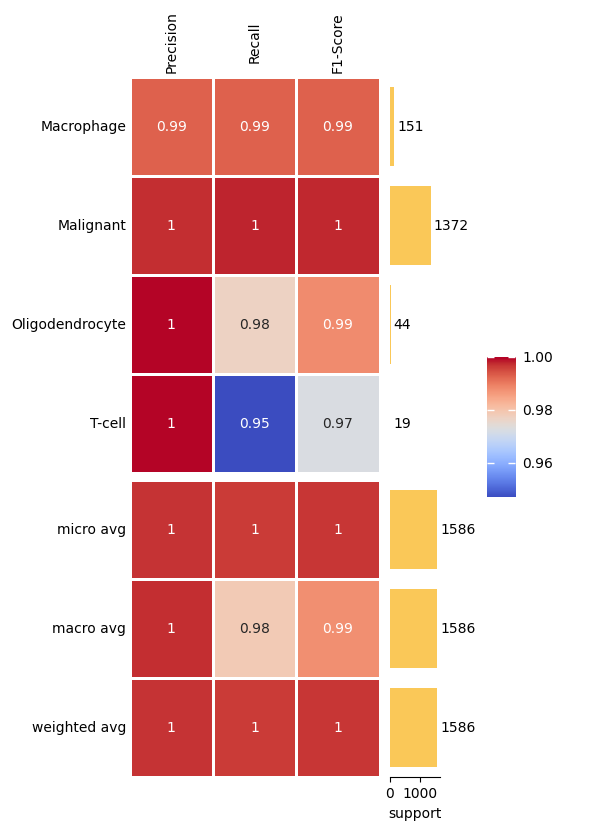

In [ ]:
# ============================================================
# 5. Informe interno de PySingleCellNet
# ============================================================

c_report_scn = cn.tl.create_classifier_report(
    adTest_scn,
    ground_truth="scn_label",
    prediction="SCN_class_argmax"
)

cn.pl.heatmap_classifier_report(c_report_scn)
plt.show()

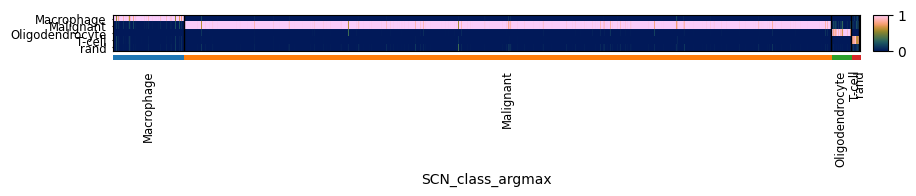

In [ ]:
# ============================================================
# 6. Heatmap de scores SingleCellNet
# ============================================================

cn.pl.heatmap_scores(
    adTest_scn,
    groupby="SCN_class_argmax"
)

plt.show()

## **3.3. Tabla final de resultados**

In [ ]:
#tabla final
df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    by="f1_macro",
    ascending=False
)

print("\n" + "="*70)
print("TABLA FINAL DE RESULTADOS")
print("="*70)

display(df_resultados.round(4))


# guardar variables
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_actinn = accuracy_score(y_test, y_pred_actinn)
acc_ct = accuracy_score(y_test, y_pred_celltypist)
acc_scn = accuracy_score(y_true_scn, y_pred_scn)


print("\nVariables guardadas:")
print("acc_svm:", acc_svm)
print("acc_rf:", acc_rf)
print("acc_actinn:", acc_actinn)
print("acc_ct:", acc_ct)
print("acc_ct:", acc_ct)
print("acc_scn:", acc_scn)


TABLA FINAL DE RESULTADOS


,modelo,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,ARI,NMI
0,SVM,0.9994,0.9943,0.9998,0.9943,0.9970,0.9994,0.9994,0.9994,0.9969,0.9918
3,CellTypist,0.9987,0.9941,0.9982,0.9941,0.9961,0.9987,0.9987,0.9987,0.9936,0.9829
2,ACTINN,0.9987,0.9812,0.9996,0.9812,0.9902,0.9987,0.9987,0.9987,0.9939,0.9841
1,Random Forest,0.9981,0.9795,0.9995,0.9795,0.9893,0.9981,0.9981,0.9981,0.9906,0.9751
4,SingleCellNet,0.9975,0.9793,0.9978,0.9793,0.9883,0.9975,0.9975,0.9975,0.9873,0.9661



Variables guardadas:
acc_svm: 0.9993694829760403
acc_rf: 0.998108448928121
acc_actinn: 0.9987389659520807
acc_ct: 0.9987389659520807
acc_ct: 0.9987389659520807
acc_scn: 0.9974763406940063


## **3.4. Visualización**

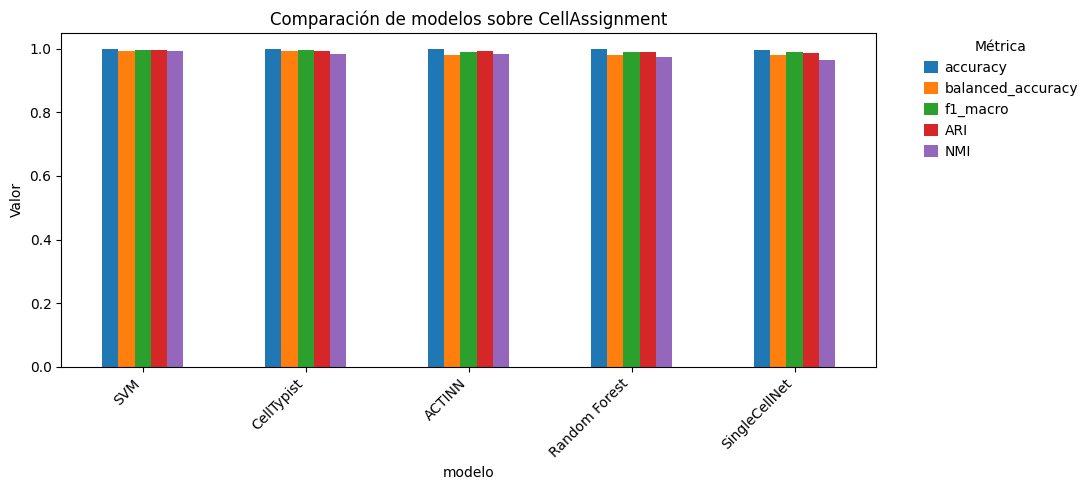

In [ ]:
import matplotlib.pyplot as plt

metricas_plot = [
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "ARI",
    "NMI"
]

df_plot = df_resultados.set_index("modelo")[metricas_plot]

ax = df_plot.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.title("Comparación de modelos sobre CellAssignment")
plt.xticks(rotation=45, ha="right")
plt.legend(
    title="Métrica",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

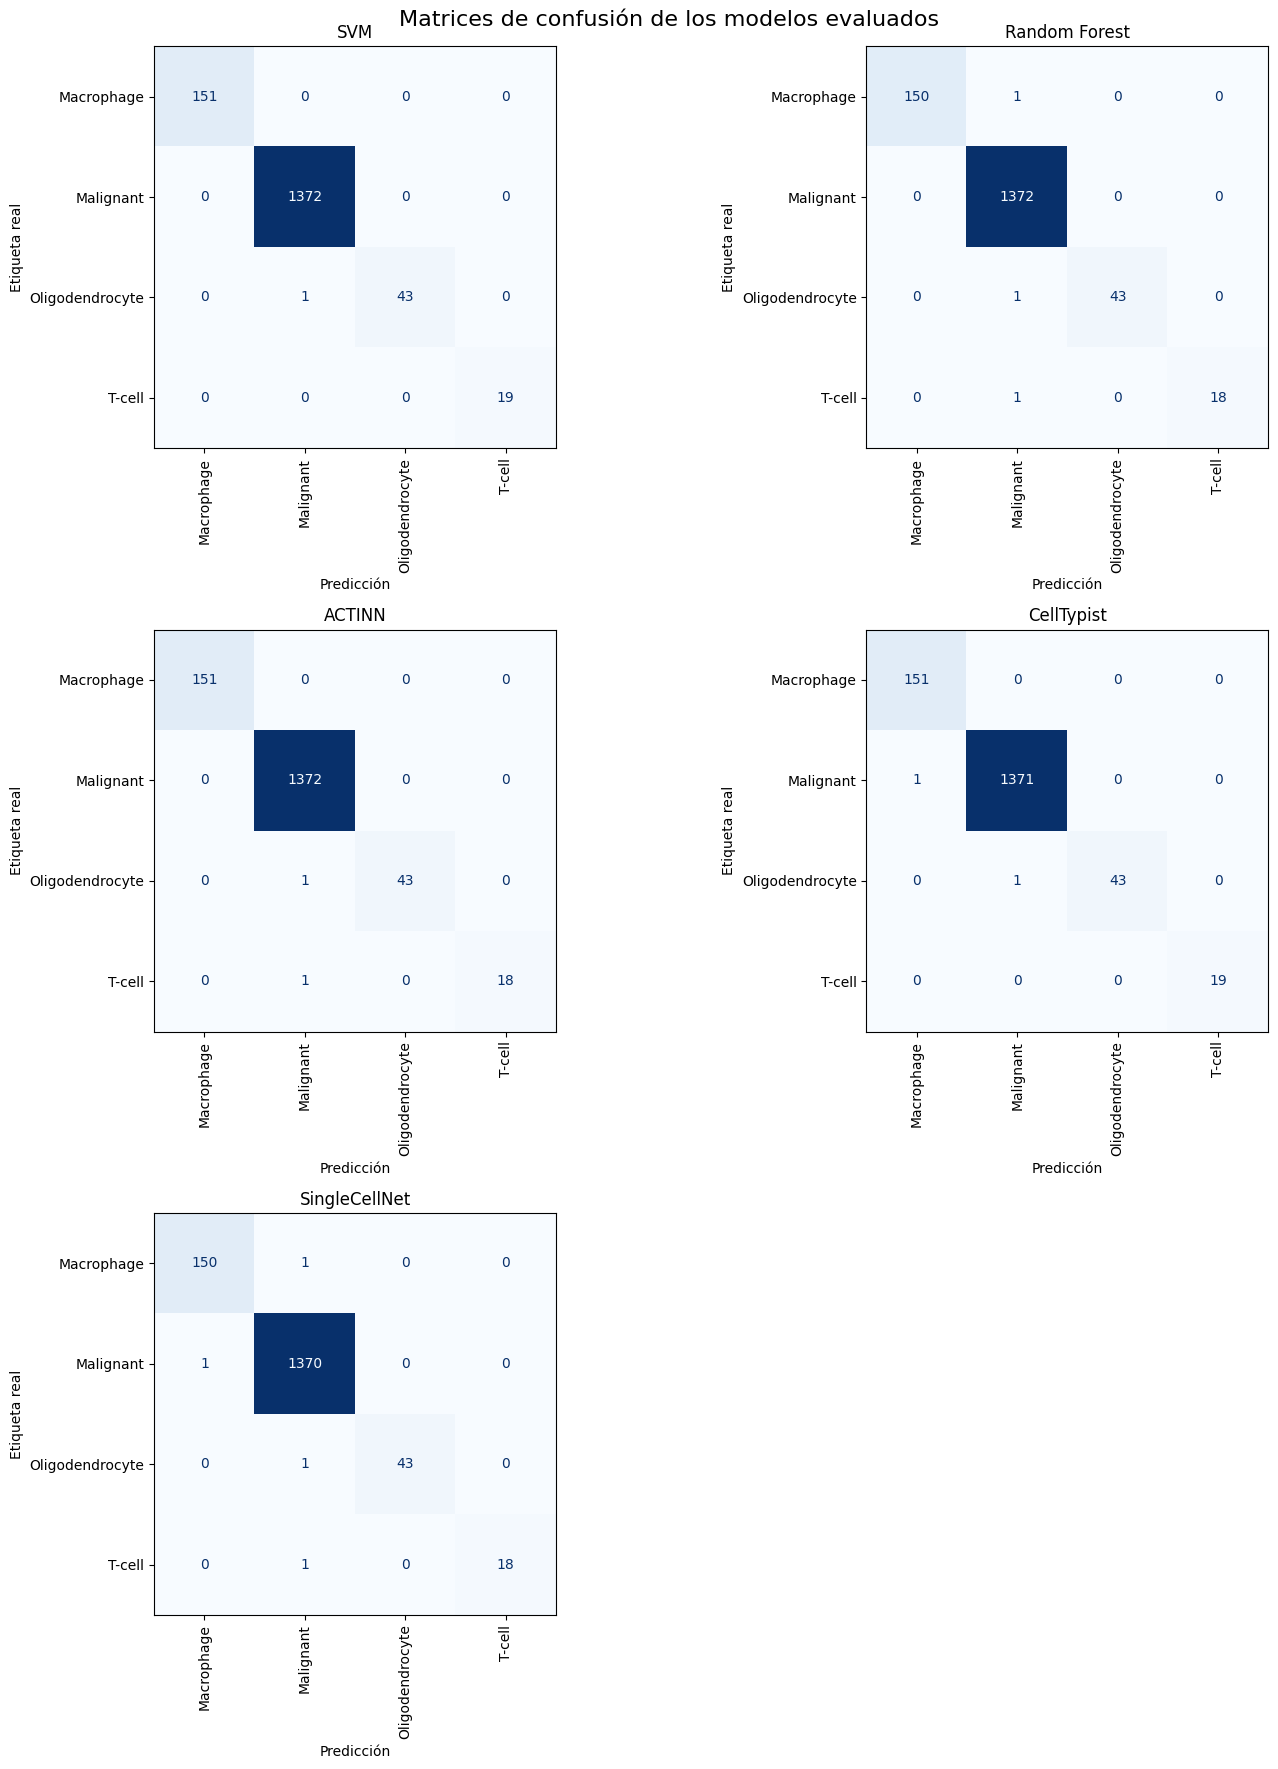

In [ ]:
#matrices de confusión

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import math

n_modelos = len(predicciones_modelos)

ncols = 2
nrows = math.ceil(n_modelos / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 6 * nrows)
)

axes = axes.flatten()

for ax, (nombre, datos) in zip(axes, predicciones_modelos.items()):

    y_true = datos["y_true"]
    y_pred = datos["y_pred"]

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=le.classes_
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        xticks_rotation=90
    )

    ax.set_title(nombre)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Etiqueta real")

for i in range(len(predicciones_modelos), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle(
    "Matrices de confusión de los modelos evaluados",
    fontsize=16
)

plt.tight_layout()
plt.show()